In [ ]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Create output directories if they don't exist
os.makedirs("../outputs/figures", exist_ok=True)
os.makedirs("../outputs/reports", exist_ok=True)

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Loading Data

In [2]:
PROCESSED_DIR = "../data/processed/"

def load_data(filename="social_cleaned.csv"):
    df = pd.read_csv(
        os.path.join(PROCESSED_DIR, filename),
        encoding="latin-1"
    )
    return df

In [3]:

social_media_data = load_data()

# Trend Name: Mental Health by Daily Usage Intensity

In [4]:
# code cell - extract trend data
usage_bins = pd.cut(social_media_data['daily_usage_hours'], bins=3, labels=['Low', 'Medium', 'High'])
trend_data = social_media_data.groupby(usage_bins)['mental_health_score'].agg(['mean', 'std', 'count'])
print(trend_data)

                       mean       std   count
daily_usage_hours                            
Low                8.020377  1.153055  543733
Medium             6.218545  1.170339  443114
High               4.120951  1.075656   13153


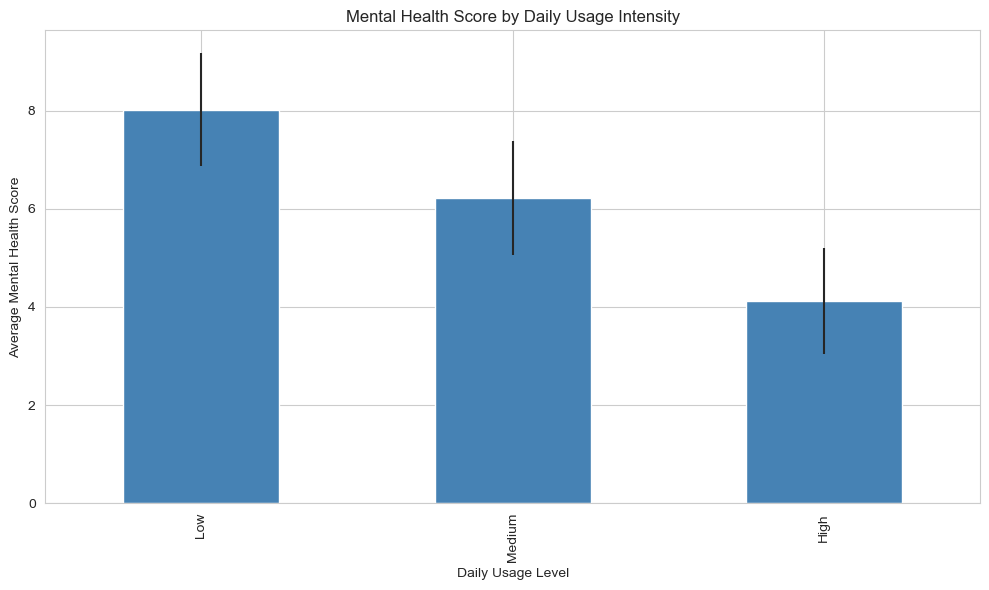

In [ ]:
# plot
fig, ax = plt.subplots(figsize=(10, 6))
trend_data['mean'].plot(kind='bar', ax=ax, color='steelblue', yerr=trend_data['std'])
ax.set_title("Mental Health Score by Daily Usage Intensity")
ax.set_ylabel("Average Mental Health Score")
ax.set_xlabel("Daily Usage Level")
plt.tight_layout()

# Save before showing
plt.savefig("../outputs/figures/mental_health_by_usage.png", dpi=300, bbox_inches='tight')
plt.show()

In [6]:
# create report
report = f"""Trend Report: Mental Health by Daily Usage Intensity
================================================

Key Findings:
- Low usage: {trend_data.loc['Low', 'mean']:.2f} (n={int(trend_data.loc['Low', 'count'])})
- Medium usage: {trend_data.loc['Medium', 'mean']:.2f} (n={int(trend_data.loc['Medium', 'count'])})
- High usage: {trend_data.loc['High', 'mean']:.2f} (n={int(trend_data.loc['High', 'count'])})

Insight: Mental health score {'decreases' if trend_data.loc['High', 'mean'] < trend_data.loc['Low', 'mean'] else 'increases'} with higher daily usage.
"""

with open("../outputs/reports/mental_health_by_usage.txt", "w") as f:
    f.write(report)

print(report)

Trend Report: Mental Health by Daily Usage Intensity

Key Findings:
- Low usage: 8.02 (n=543733)
- Medium usage: 6.22 (n=443114)
- High usage: 4.12 (n=13153)

Insight: Mental health score decreases with higher daily usage.



# Mental Health by Country

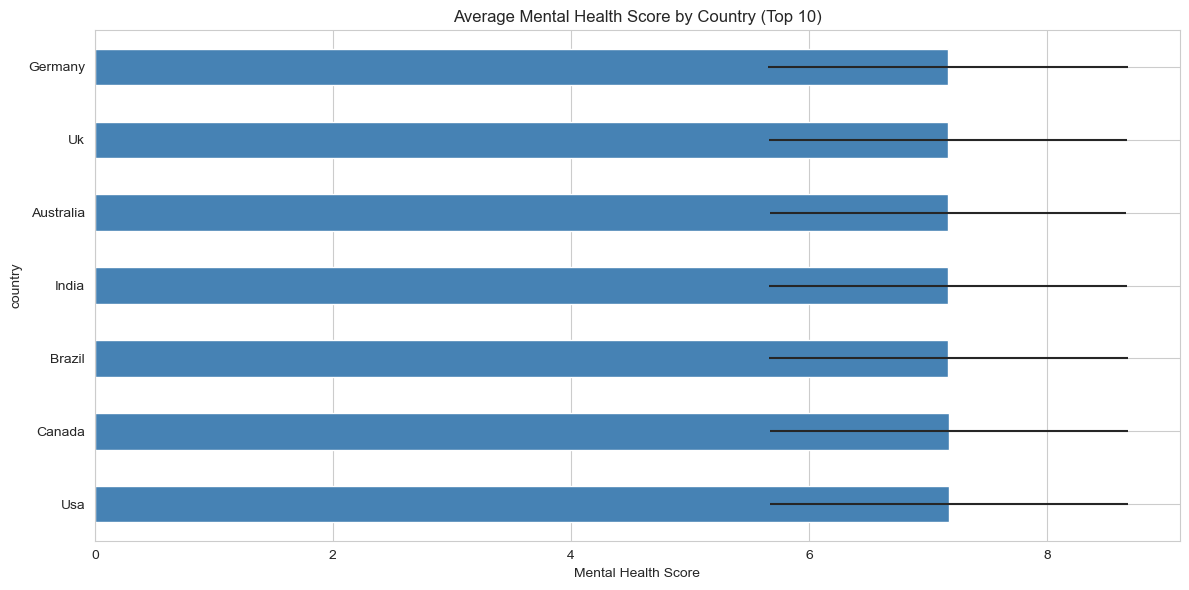

Trend Report: Mental Health by Country (Top 10)
Top 3: Usa (7.18), Canada (7.17), Brazil (7.17)
Average: 7.17
Range: 7.16 to 7.18



In [7]:
# Analyze
country_trend = (
    social_media_data.groupby('country')['mental_health_score']
    .agg(['mean', 'std', 'count'])
    .sort_values('mean', ascending=False)
    .head(10)
)

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
country_trend['mean'].plot(kind='barh', ax=ax, color='steelblue', xerr=country_trend['std'])
ax.set_title("Average Mental Health Score by Country (Top 10)")
ax.set_xlabel("Mental Health Score")
plt.tight_layout()
plt.savefig("../outputs/figures/mental_health_by_country.png", dpi=300, bbox_inches='tight')
plt.show()

# Report
report = f"""Trend Report: Mental Health by Country (Top 10)
==================================================
Top 3: {country_trend.index[0]} ({country_trend.iloc[0]['mean']:.2f}), {country_trend.index[1]} ({country_trend.iloc[1]['mean']:.2f}), {country_trend.index[2]} ({country_trend.iloc[2]['mean']:.2f})
Average: {country_trend['mean'].mean():.2f}
Range: {country_trend['mean'].min():.2f} to {country_trend['mean'].max():.2f}
"""
with open("../outputs/reports/mental_health_by_country.txt", "w") as f:
    f.write(report)
print(report)